# EDA, DATA PREPARATION AND MODEL BUILDING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import CategoricalDtype


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

sns.set_theme(style="whitegrid", context="notebook")

## LOAD AND STACK DATA

In [2]:
data_19 = pd.read_csv('../datasets/DATASET_2019.csv')
data_21 = pd.read_csv('../datasets/DATASET_2021.csv')
data_23 = pd.read_csv('../datasets/DATASET_2023.csv')

In [3]:
datasets = [data_19, data_21, data_23]
for data in datasets:
    print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 416661 entries, 0 to 416660
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   year                           416661 non-null  int64  
 1   age_group_00                   410146 non-null  str    
 2   age_00                         410146 non-null  float64
 3   sex_00                         416661 non-null  str    
 4   race_00                        407891 non-null  str    
 5   weight_00                      387477 non-null  float64
 6   height_00                      398396 non-null  float64
 7   bmi_00                         383076 non-null  float64
 8   marital_status_00              413299 non-null  str    
 9   education_level_00             414922 non-null  str    
 10  education_00                   414922 non-null  float64
 11  employment_status_00           410363 non-null  str    
 12  income_level_00                337595 non

In [4]:
for data in datasets:
    print(data.columns, len(data.columns))

Index(['year', 'age_group_00', 'age_00', 'sex_00', 'race_00', 'weight_00',
       'height_00', 'bmi_00', 'marital_status_00', 'education_level_00',
       'education_00', 'employment_status_00', 'income_level_00', 'income_00',
       'general_health_00', 'gen_health_00', 'physical_health_days_00',
       'mental_health_days_00', 'poor_health_days_00', 'exercise_00',
       'smoked_100_cigarettes_00', 'drinks_alcohol_00', 'avg_drinks_p_day_00',
       'high_bp_00', 'high_cholesterol_00', 'had_stroke_00',
       'had_heart_attack_00', 'had_coronary_heart_disease_00',
       'cost_barrier_00', 'last_checkup_00', 'l_checkup_00',
       'has_personal_doctor_00', 'diabetes'],
      dtype='str') 33
Index(['year', 'age_group_00', 'age_00', 'sex_00', 'race_00', 'weight_00',
       'height_00', 'bmi_00', 'marital_status_00', 'education_level_00',
       'education_00', 'employment_status_00', 'income_level_01', 'income_01',
       'general_health_00', 'gen_health_00', 'physical_health_days_00',


### Fix column name mismatch in 2019 data
- income_level_00 => income_level_01
- income_00 => income_01

In [5]:
data_19.rename(columns={"income_level_00": "income_level_01", "income_00":"income_01"}, inplace=True)

Concatenate all data across the 3 years, preserving all columns.

In [6]:
combined_data = pd.concat(datasets, ignore_index=True, join="outer", axis=0)
combined_data.head()

,year,age_group_00,age_00,sex_00,race_00,weight_00,height_00,bmi_00,marital_status_00,education_level_00,education_00,employment_status_00,income_level_01,income_01,general_health_00,gen_health_00,physical_health_days_00,mental_health_days_00,poor_health_days_00,exercise_00,smoked_100_cigarettes_00,drinks_alcohol_00,avg_drinks_p_day_00,high_bp_00,high_cholesterol_00,had_stroke_00,had_heart_attack_00,had_coronary_heart_disease_00,cost_barrier_00,last_checkup_00,l_checkup_00,has_personal_doctor_00,diabetes
0,2019,40 to 44,5.0,Female,White,220.0,66.0,35.51,Never married,College 1 year to 3 years (Some college or technical school),5.0,A homemaker,"Less than $10,000",1.0,Very Good,2.0,0.0,30.0,30.0,False,True,False,NaN,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Non-diabetic
1,2019,60 to 64,9.0,Male,White,150.0,66.0,24.21,Divorced,College 1 year to 3 years (Some college or technical school),5.0,Unable to work,"Less than $10,000",1.0,Fair,4.0,3.0,12.0,5.0,True,True,False,NaN,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
2,2019,45 to 49,6.0,Female,White,148.0,61.0,27.96,Divorced,Grade 12 or GED (High school graduate),4.0,Employed for wages,"Less than $10,000",1.0,Good,3.0,0.0,10.0,5.0,True,True,True,2.0,Yes,True,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic
3,2019,45 to 49,6.0,Male,White,220.0,71.0,30.68,Married,Grade 12 or GED (High school graduate),4.0,Employed for wages,"$75,000 or more",8.0,Very Good,2.0,0.0,0.0,NaN,True,True,False,NaN,No,False,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
4,2019,65 to 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,Grade 12 or GED (High school graduate),4.0,Retired,"$15,000 to less than $20,000",3.0,Fair,4.0,30.0,0.0,30.0,False,True,False,NaN,Yes,True,True,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic


In [7]:
combined_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1285657 entries, 0 to 1285656
Data columns (total 33 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   year                           1285657 non-null  int64  
 1   age_group_00                   1262286 non-null  str    
 2   age_00                         1262286 non-null  float64
 3   sex_00                         1285657 non-null  str    
 4   race_00                        1256801 non-null  str    
 5   weight_00                      1182980 non-null  float64
 6   height_00                      1221773 non-null  float64
 7   bmi_00                         1170319 non-null  float64
 8   marital_status_00              1273395 non-null  str    
 9   education_level_00             1279423 non-null  str    
 10  education_00                   1279423 non-null  float64
 11  employment_status_00           1263926 non-null  str    
 12  income_level_01          

### Save Stacked Data

In [9]:
combined_data.to_csv('../datasets/combined_19_21_23.csv', index=False)

## EDA and Data Cleaning

In [2]:
df = pd.read_csv('../datasets/combined_19_21_23.csv')
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1285657 entries, 0 to 1285656
Data columns (total 33 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   year                           1285657 non-null  int64  
 1   age_group_00                   1262286 non-null  str    
 2   age_00                         1262286 non-null  float64
 3   sex_00                         1285657 non-null  str    
 4   race_00                        1256801 non-null  str    
 5   weight_00                      1182980 non-null  float64
 6   height_00                      1221773 non-null  float64
 7   bmi_00                         1170319 non-null  float64
 8   marital_status_00              1273395 non-null  str    
 9   education_level_00             1279423 non-null  str    
 10  education_00                   1279423 non-null  float64
 11  employment_status_00           1263926 non-null  str    
 12  income_level_01          

,year,age_group_00,age_00,sex_00,race_00,weight_00,height_00,bmi_00,marital_status_00,education_level_00,education_00,employment_status_00,income_level_01,income_01,general_health_00,gen_health_00,physical_health_days_00,mental_health_days_00,poor_health_days_00,exercise_00,smoked_100_cigarettes_00,drinks_alcohol_00,avg_drinks_p_day_00,high_bp_00,high_cholesterol_00,had_stroke_00,had_heart_attack_00,had_coronary_heart_disease_00,cost_barrier_00,last_checkup_00,l_checkup_00,has_personal_doctor_00,diabetes
0,2019,40 to 44,5.0,Female,White,220.0,66.0,35.51,Never married,College 1 year to 3 years (Some college or technical school),5.0,A homemaker,"Less than $10,000",1.0,Very Good,2.0,0.0,30.0,30.0,False,True,False,NaN,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Non-diabetic
1,2019,60 to 64,9.0,Male,White,150.0,66.0,24.21,Divorced,College 1 year to 3 years (Some college or technical school),5.0,Unable to work,"Less than $10,000",1.0,Fair,4.0,3.0,12.0,5.0,True,True,False,NaN,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
2,2019,45 to 49,6.0,Female,White,148.0,61.0,27.96,Divorced,Grade 12 or GED (High school graduate),4.0,Employed for wages,"Less than $10,000",1.0,Good,3.0,0.0,10.0,5.0,True,True,True,2.0,Yes,True,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic
3,2019,45 to 49,6.0,Male,White,220.0,71.0,30.68,Married,Grade 12 or GED (High school graduate),4.0,Employed for wages,"$75,000 or more",8.0,Very Good,2.0,0.0,0.0,NaN,True,True,False,NaN,No,False,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
4,2019,65 to 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,Grade 12 or GED (High school graduate),4.0,Retired,"$15,000 to less than $20,000",3.0,Fair,4.0,30.0,0.0,30.0,False,True,False,NaN,Yes,True,True,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic


In [3]:
df.isna().sum()

year                                  0
age_group_00                      23371
age_00                            23371
sex_00                                0
race_00                           28856
weight_00                        102677
height_00                         63884
bmi_00                           115338
marital_status_00                 12262
education_level_00                 6234
education_00                       6234
employment_status_00              21731
income_level_01                  258424
income_01                        258424
general_health_00                  3318
gen_health_00                      3318
physical_health_days_00           30333
mental_health_days_00             24451
poor_health_days_00              589923
exercise_00                       23624
smoked_100_cigarettes_00          64272
drinks_alcohol_00                 82303
avg_drinks_p_day_00              675409
high_bp_00                         4817
high_cholesterol_00              146900


> To fix:
- Handle missing data
- Rename columns, remove the suffixes

In [3]:
clean_column_names = {}

for column in df.columns:
    # split by underscores, and remove the last part, then join
    if '_' in column:
        clean_name = '_'.join(column.strip().split('_')[:-1])
        clean_column_names[column] = clean_name
    else:
        clean_column_names[column] = column.strip()
    
clean_column_names

{'year': 'year',
 'age_group_00': 'age_group',
 'age_00': 'age',
 'sex_00': 'sex',
 'race_00': 'race',
 'weight_00': 'weight',
 'height_00': 'height',
 'bmi_00': 'bmi',
 'marital_status_00': 'marital_status',
 'education_level_00': 'education_level',
 'education_00': 'education',
 'employment_status_00': 'employment_status',
 'income_level_01': 'income_level',
 'income_01': 'income',
 'general_health_00': 'general_health',
 'gen_health_00': 'gen_health',
 'physical_health_days_00': 'physical_health_days',
 'mental_health_days_00': 'mental_health_days',
 'poor_health_days_00': 'poor_health_days',
 'exercise_00': 'exercise',
 'smoked_100_cigarettes_00': 'smoked_100_cigarettes',
 'drinks_alcohol_00': 'drinks_alcohol',
 'avg_drinks_p_day_00': 'avg_drinks_p_day',
 'high_bp_00': 'high_bp',
 'high_cholesterol_00': 'high_cholesterol',
 'had_stroke_00': 'had_stroke',
 'had_heart_attack_00': 'had_heart_attack',
 'had_coronary_heart_disease_00': 'had_coronary_heart_disease',
 'cost_barrier_00': '

In [4]:
df.rename(columns=clean_column_names, inplace=True)
df.head()

,year,age_group,age,sex,race,weight,height,bmi,marital_status,education_level,education,employment_status,income_level,income,general_health,gen_health,physical_health_days,mental_health_days,poor_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,avg_drinks_p_day,high_bp,high_cholesterol,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,last_checkup,l_checkup,has_personal_doctor,diabetes
0,2019,40 to 44,5.0,Female,White,220.0,66.0,35.51,Never married,College 1 year to 3 years (Some college or technical school),5.0,A homemaker,"Less than $10,000",1.0,Very Good,2.0,0.0,30.0,30.0,False,True,False,NaN,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Non-diabetic
1,2019,60 to 64,9.0,Male,White,150.0,66.0,24.21,Divorced,College 1 year to 3 years (Some college or technical school),5.0,Unable to work,"Less than $10,000",1.0,Fair,4.0,3.0,12.0,5.0,True,True,False,NaN,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
2,2019,45 to 49,6.0,Female,White,148.0,61.0,27.96,Divorced,Grade 12 or GED (High school graduate),4.0,Employed for wages,"Less than $10,000",1.0,Good,3.0,0.0,10.0,5.0,True,True,True,2.0,Yes,True,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic
3,2019,45 to 49,6.0,Male,White,220.0,71.0,30.68,Married,Grade 12 or GED (High school graduate),4.0,Employed for wages,"$75,000 or more",8.0,Very Good,2.0,0.0,0.0,NaN,True,True,False,NaN,No,False,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
4,2019,65 to 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,Grade 12 or GED (High school graduate),4.0,Retired,"$15,000 to less than $20,000",3.0,Fair,4.0,30.0,0.0,30.0,False,True,False,NaN,Yes,True,True,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic


#### Deal with missing data
- Drop all rows where age is missing
- Race is not to be used. Might drop the column altogether
- Verify where weight, height and bmi are missing
- drop all where bmi is missing

In [6]:
df.isna().sum()

year                               0
age_group                      23371
age                            23371
sex                                0
race                           28856
weight                        102677
height                         63884
bmi                           115338
marital_status                 12262
education_level                 6234
education                       6234
employment_status              21731
income_level                  258424
income                        258424
general_health                  3318
gen_health                      3318
physical_health_days           30333
mental_health_days             24451
poor_health_days              589923
exercise                       23624
smoked_100_cigarettes          64272
drinks_alcohol                 82303
avg_drinks_p_day              675409
high_bp                         4817
high_cholesterol              146900
had_stroke                      3452
had_heart_attack                6971
h

In [21]:
df[['age', 'age_group']][df['age'].isna()]

,age,age_group
70,NaN,NaN
83,NaN,NaN
193,NaN,NaN
236,NaN,NaN
562,NaN,NaN
...,...,...
1285449,NaN,NaN
1285484,NaN,NaN
1285499,NaN,NaN
1285505,NaN,NaN


In [7]:
# check if any of the rows have two of the parameters to infer the third
cols = ['weight', 'height', 'bmi']
df[df[cols].notna().sum(axis=1) == 2][cols]

,weight,height,bmi


In [15]:
df_1 = df.copy()
df_1.drop(columns=['poor_health_days', 'avg_drinks_p_day', 'high_cholesterol'], inplace=True)
df_1.dropna(inplace=True)
df_1.info()

<class 'pandas.DataFrame'>
Index: 869319 entries, 0 to 1285656
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   year                        869319 non-null  int64  
 1   age_group                   869319 non-null  str    
 2   age                         869319 non-null  float64
 3   sex                         869319 non-null  str    
 4   race                        869319 non-null  str    
 5   weight                      869319 non-null  float64
 6   height                      869319 non-null  float64
 7   bmi                         869319 non-null  float64
 8   marital_status              869319 non-null  str    
 9   education_level             869319 non-null  str    
 10  education                   869319 non-null  float64
 11  employment_status           869319 non-null  str    
 12  income_level                869319 non-null  str    
 13  income                      8

In [36]:
df.diabetes.value_counts()

diabetes
Non-diabetic    1081246
Diabetic         174727
Pre-diabetic      29684
Name: count, dtype: int64

In [37]:
df_1.diabetes.value_counts()

diabetes
Non-diabetic    734009
Diabetic        115697
Pre-diabetic     19613
Name: count, dtype: int64

#### Fix category orders
- age_group
- education_level
- income_level
- gen_health
- last_checkup

In [29]:
df_1.age_group.unique()

<ArrowStringArray>
[   '40 to 44',    '60 to 64',    '45 to 49',    '65 to 69',    '55 to 59',
    '18 to 24',    '50 to 54', '80 or older',    '75 to 79',    '25 to 29',
    '35 to 39',    '70 to 74',    '30 to 34']
Length: 13, dtype: str

In [16]:
# fix age_group order
age_categories = ['18 to 24', '25 to 29', '30 to 34', '35 to 39', '40 to 44', '45 to 49', '50 to 54', '55 to 59', '60 to 64',
                  '65 to 69', '70 to 74', '75 or older']
age_cat_type = CategoricalDtype(categories=age_categories, ordered=True)
# Apply to a column
df_1['age_group'] = df_1['age_group'].astype(age_cat_type)

/tmp/ipykernel_94508/2825200030.py:6: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_1['age_group'] = df_1['age_group'].astype(age_cat_type)


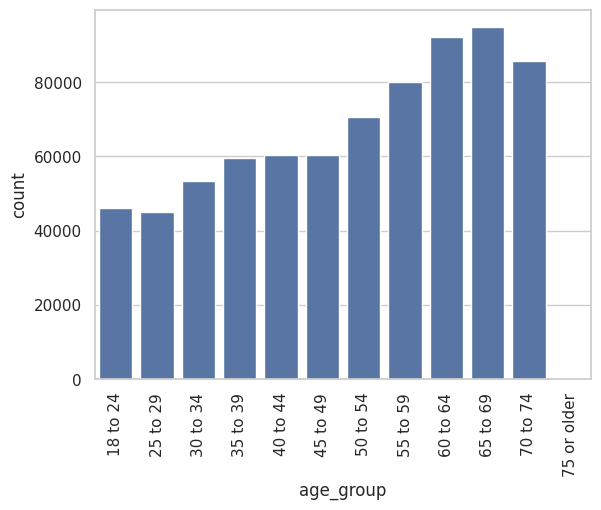

In [17]:
sns.countplot(data=df_1, x='age_group')
plt.xticks(rotation=90);

In [38]:
df_1.education_level.unique()

<ArrowStringArray>
['College 1 year to 3 years (Some college or technical school)',
                       'Grade 12 or GED (High school graduate)',
                   'College 4 years or more (College graduate)',
                             'Grades 9 - 11 (Some high school)',
                                    'Grades 1 - 8 (Elementary)',
                   'Never attended school or only kindergarten']
Length: 6, dtype: str

In [18]:
# fix education_level order
rename = {
    "Never attended school or only kindergarten" : "None or KG",
    "Grades 1 - 8 (Elementary)": "Elementary (1-8)",
    "Grades 9 - 11 (Some high school)": "Some high school (9-11)",
    "Grade 12 or GED (High school graduate)": "High school graduate (12 or GED)",
    "College 1 year to 3 years (Some college or technical school)": "Some college (1-3 years) or Technical school",
    "College 4 years or more (College graduate)": "Collge graduate (4+ years)"
}

df_1['education_level'] = df_1['education_level'].replace(rename)


education_categories = ['None or KG', 'Elementary (1-8)', 'Some high school (9-11)', 'High school graduate (12 or GED)',
                        'Some college (1-3 years) or Technical school', 'College graduate (4+ years)']
education_cat_type = CategoricalDtype(categories=education_categories, ordered=True)
# Apply to a column
df_1['education_level'] = df_1['education_level'].astype(education_cat_type)

/tmp/ipykernel_94508/3898821903.py:18: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_1['education_level'] = df_1['education_level'].astype(education_cat_type)


In [8]:
df_1.education_level.unique()

['Some college (1-3 years) or Technical school', 'High school graduate (12 or GED)', NaN, 'Some high school (9-11)', 'Elementary (1-8)', 'None or KG']
Categories (6, str): ['None or KG' < 'Elementary (1-8)' < 'Some high school (9-11)' < 'High school graduate (12 or GED)' < 'Some college (1-3 years) or Technical school' < 'College graduate (4+ years)']

In [44]:
df_1.income_level.unique()

<ArrowStringArray>
[             'Less than $10,000',                '$75,000 or more',
   '$15,000 to less than $20,000',   '$35,000 to less than $50,000',
   '$20,000 to less than $25,000',   '$50,000 to less than $75,000',
   '$25,000 to less than $35,000',   '$10,000 to less than $15,000',
               '$200,000 or more', '$100,000 to less than $150,000',
  '$75,000 to less than $100,000', '$150,000 to less than $200,000']
Length: 12, dtype: str

In [19]:
# fix income_level order

rename_income = {
    'Less than $10,000': '<$10,000',
    '$10,000 to less than $15,000': '$10,000 - <$15,000',
    '$15,000 to less than $20,000': '$15,000 - <$20,000',
    '$20,000 to less than $25,000': '$20,000 - <$25,000',
    '$25,000 to less than $35,000': '$25,000 - <$35,000',
    '$35,000 to less than $50,000': '$35,000 - <$50,000',
    '$50,000 to less than $75,000': '$50,000 - <$75,000',
    '$75,000 or more': '$75,000 - <$100,000',
    '$75,000 to less than $100,000': '$75,000 - <$100,000',
    '$100,000 to less than $150,000': '$100,000 - <$150,000',
    '$150,000 to less than $200,000': '$150,000 - <$200,000',
    '$200,000 or more': '$200,000+'
}

df_1['income_level'] = df_1["income_level"].replace(rename_income)


income_categories = ['<$10,000', '$10,000 - <$15,000', '$15,000 - <$20,000', '$20,000 - <$25,000', '$25,000 - <$35,000',
                     '$35,000 - <$50,000', '$50,000 - <$75,000', '$75,000 - <$100,000', '$100,000 - <$150,000',
                     '$150,000 - <$200,000', '$200,000+']
income_cat_type = CategoricalDtype(categories=income_categories, ordered=True)
# Apply to a column
df_1['income_level'] = df_1['income_level'].astype(income_cat_type)


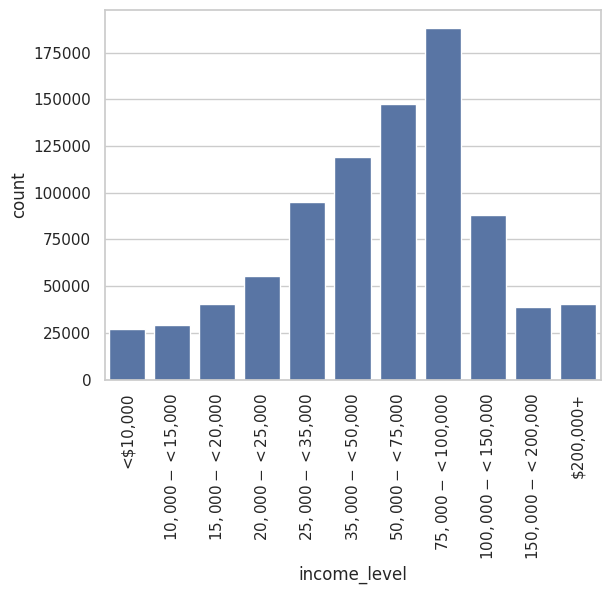

In [20]:
sns.countplot(data=df_1, x='income_level')
plt.xticks(rotation=90);

<Axes: xlabel='general_health', ylabel='count'>

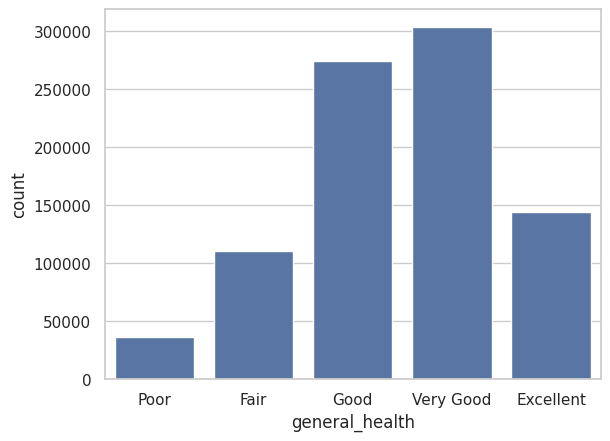

In [23]:
# fix general_health order
df_1.general_health.unique()
health_order = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']

health_cat_type = CategoricalDtype(categories=health_order, ordered=True)
df_1['general_health'] = df_1['general_health'].astype(health_cat_type)

sns.countplot(data=df_1, x='general_health')

In [26]:
df_1.last_checkup.unique()

<ArrowStringArray>
[     'Within the past year (< 12 months ago)',
                         '5 or more years ago',
 'Within the past 2 years (1 to <2 years ago)',
 'Within the past 5 years (2 to <5 years ago)',
                                       'Never']
Length: 5, dtype: str

In [ ]:
rename_checkup = {
    "Never": "Never",
    "5 or more years ago": ">5 years",
    "Within the past 5 years (2 to <5 years ago)": "2 - <5 years",
    "Within the past 2 years (1 to <2 years ago)": "1 - <2 years",
    "Within the past year (< 12 months ago)": "<1 year",
}
df_1['last_checkup'] = df_1['last_checkup'].replace(rename_checkup)
df_1.last_checkup.unique()

order_checkup = ['Never', '>5 years', '2 - <5 years', '1 - <2 years', '<1 year']
checkup_cat_type = CategoricalDtype(categories=order_checkup, ordered=True)
df_1['last_checkup'] = df_1['last_checkup'].astype(checkup_cat_type)

<ArrowStringArray>
['<1 year', '>5 years', '1 - <2 years', '2 - <5 years', 'Never']
Length: 5, dtype: str

In [30]:
df_1.info()

<class 'pandas.DataFrame'>
Index: 869319 entries, 0 to 1285656
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   year                        869319 non-null  int64   
 1   age_group                   748262 non-null  category
 2   age                         869319 non-null  float64 
 3   sex                         869319 non-null  str     
 4   race                        869319 non-null  str     
 5   weight                      869319 non-null  float64 
 6   height                      869319 non-null  float64 
 7   bmi                         869319 non-null  float64 
 8   marital_status              869319 non-null  str     
 9   education_level             492180 non-null  category
 10  education                   869319 non-null  float64 
 11  employment_status           869319 non-null  str     
 12  income_level                869319 non-null  category
 13  income        

In [31]:
df_1.to_csv('../datasets/cleaned_data.csv', index=False)

In [32]:
# function to preserve order of categories when saving to csv and loading back
def load_with_category_order(filename):
    df = pd.read_csv(filename)


    # fix age_group order
    age_categories = ['18 to 24', '25 to 29', '30 to 34', '35 to 39', '40 to 44', '45 to 49', '50 to 54', '55 to 59', '60 to 64',
                    '65 to 69', '70 to 74', '75 or older']
    age_cat_type = CategoricalDtype(categories=age_categories, ordered=True)
    # Apply to a column
    df['age_group'] = df['age_group'].astype(age_cat_type)

    
    # fix education_level order
    rename_education = {
        "Never attended school or only kindergarten" : "None or KG",
        "Grades 1 - 8 (Elementary)": "Elementary (1-8)",
        "Grades 9 - 11 (Some high school)": "Some high school (9-11)",
        "Grade 12 or GED (High school graduate)": "High school graduate (12 or GED)",
        "College 1 year to 3 years (Some college or technical school)": "Some college (1-3 years) or Technical school",
        "College 4 years or more (College graduate)": "Collge graduate (4+ years)"
    }

    df['education_level'] = df['education_level'].replace(rename_education)


    education_categories = ['None or KG', 'Elementary (1-8)', 'Some high school (9-11)', 'High school graduate (12 or GED)',
                            'Some college (1-3 years) or Technical school', 'College graduate (4+ years)']
    education_cat_type = CategoricalDtype(categories=education_categories, ordered=True)
    # Apply to a column
    df['education_level'] = df['education_level'].astype(education_cat_type)


    # fix income_level order
    rename_income = {
        'Less than $10,000': '<$10,000',
        '$10,000 to less than $15,000': '$10,000 - <$15,000',
        '$15,000 to less than $20,000': '$15,000 - <$20,000',
        '$20,000 to less than $25,000': '$20,000 - <$25,000',
        '$25,000 to less than $35,000': '$25,000 - <$35,000',
        '$35,000 to less than $50,000': '$35,000 - <$50,000',
        '$50,000 to less than $75,000': '$50,000 - <$75,000',
        '$75,000 or more': '$75,000 - <$100,000',
        '$75,000 to less than $100,000': '$75,000 - <$100,000',
        '$100,000 to less than $150,000': '$100,000 - <$150,000',
        '$150,000 to less than $200,000': '$150,000 - <$200,000',
        '$200,000 or more': '$200,000+'
    }

    df['income_level'] = df["income_level"].replace(rename_income)


    income_categories = ['<$10,000', '$10,000 - <$15,000', '$15,000 - <$20,000', '$20,000 - <$25,000', '$25,000 - <$35,000',
                        '$35,000 - <$50,000', '$50,000 - <$75,000', '$75,000 - <$100,000', '$100,000 - <$150,000',
                        '$150,000 - <$200,000', '$200,000+']
    income_cat_type = CategoricalDtype(categories=income_categories, ordered=True)
    # Apply to a column
    df['income_level'] = df['income_level'].astype(income_cat_type)


    # fix general_health order
    df.general_health.unique()
    health_order = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']

    health_cat_type = CategoricalDtype(categories=health_order, ordered=True)
    df['general_health'] = df['general_health'].astype(health_cat_type)

    sns.countplot(data=df, x='general_health')

    # fix last_checkup order
    rename_checkup = {
        "Never": "Never",
        "5 or more years ago": ">5 years",
        "Within the past 5 years (2 to <5 years ago)": "2 - <5 years",
        "Within the past 2 years (1 to <2 years ago)": "1 - <2 years",
        "Within the past year (< 12 months ago)": "<1 year",
    }
    df['last_checkup'] = df['last_checkup'].replace(rename_checkup)
    df.last_checkup.unique()

    order_checkup = ['Never', '>5 years', '2 - <5 years', '1 - <2 years', '<1 year']
    checkup_cat_type = CategoricalDtype(categories=order_checkup, ordered=True)
    df['last_checkup'] = df['last_checkup'].astype(checkup_cat_type)


    return df


<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   year                        869319 non-null  int64   
 1   age_group                   748262 non-null  category
 2   age                         869319 non-null  float64 
 3   sex                         869319 non-null  str     
 4   race                        869319 non-null  str     
 5   weight                      869319 non-null  float64 
 6   height                      869319 non-null  float64 
 7   bmi                         869319 non-null  float64 
 8   marital_status              869319 non-null  str     
 9   education_level             492180 non-null  category
 10  education                   869319 non-null  float64 
 11  employment_status           869319 non-null  str     
 12  income_level                869319 non-null  category
 13  income    

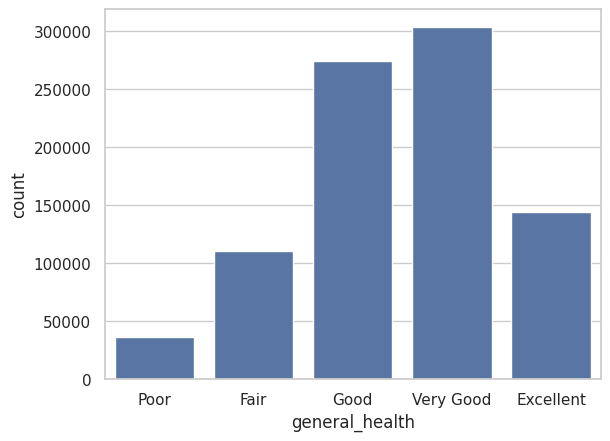

In [33]:
df = load_with_category_order("../datasets/cleaned_data.csv")
df.info()